# Домашнє завдання №6: лінійна регресія

У роботі реалізовано векторизовану лінійну регресію трьома способами:

1. градієнтний спуск, реалізований вручну;
2. аналітичне рішення за допомогою псевдооберненої матриці;
3. `LinearRegression` із бібліотеки scikit-learn.

Навчання виконується виключно на завантаженому датасеті `Housing.csv`; синтетичні навчальні дані не створюються.

Мета — спрогнозувати ціну будинку за площею (`area`), кількістю ванних кімнат
(`bathrooms`) та кількістю спалень (`bedrooms`).

Джерело: [Housing.csv (Google Drive)](https://drive.google.com/file/d/1-rAa4XT4_fI0dOBlMNuE6a7jB0wln_Qo/view?usp=share_link).

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.set_printoptions(precision=6, suppress=True)
pd.set_option("display.float_format", "{:.6f}".format)
plt.style.use("seaborn-v0_8-whitegrid")

print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

NumPy: 2.3.5
Pandas: 3.0.1


## 1. Завантаження та первинний огляд даних

In [2]:
from pathlib import Path
from urllib.request import urlretrieve

DATASET_URL = (
    "https://drive.usercontent.google.com/download"
    "?id=1-rAa4XT4_fI0dOBlMNuE6a7jB0wln_Qo&export=download&confirm=t"
)
DATASET_PATH = Path("Housing.csv")

# Якщо CSV ще не лежить поруч із ноутбуком, завантажуємо саме наданий датасет.
if not DATASET_PATH.exists():
    urlretrieve(DATASET_URL, DATASET_PATH)

df = pd.read_csv(DATASET_PATH)
print(f"Завантажено реальний датасет: {DATASET_PATH.resolve()}")
print("Розмір датасету:", df.shape)
print("Кількість пропусків у потрібних колонках:")
print(df[["price", "area", "bathrooms", "bedrooms"]].isna().sum())
df.head()

Завантажено реальний датасет: C:\Users\matsa\PyCharmMiscProject\Dz_matsafei\goit-ds-hw-jupyter\hw6\Housing.csv
Розмір датасету: (545, 13)
Кількість пропусків у потрібних колонках:
price        0
area         0
bathrooms    0
bedrooms     0
dtype: int64


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Для моделі використовуємо три ознаки в такому порядку:
`area`, `bathrooms`, `bedrooms`. Цільова змінна — `price`.

In [3]:
feature_names = ["area", "bathrooms", "bedrooms"]
X_raw = df[feature_names].to_numpy(dtype=float)
y_raw = df["price"].to_numpy(dtype=float)

print("Форма X:", X_raw.shape)
print("Форма y:", y_raw.shape)
df[["price", *feature_names]].describe()

Форма X: (545, 3)
Форма y: (545,)


,price,area,bathrooms,bedrooms
count,545.000000,545.000000,545.000000,545.000000
mean,4766729.247706,5150.541284,1.286239,2.965138
std,1870439.615657,2170.141023,0.502470,0.738064
min,1750000.000000,1650.000000,1.000000,1.000000
25%,3430000.000000,3600.000000,1.000000,2.000000
50%,4340000.000000,4600.000000,1.000000,3.000000
75%,5740000.000000,6360.000000,2.000000,3.000000
max,13300000.000000,16200.000000,4.000000,6.000000


## 2. Функція гіпотези у векторному вигляді

In [4]:
def hypothesis(X, w):
    """Повертає вектор прогнозів h_w(X) = X @ w."""
    return X @ w


# Перевіряємо функцію на перших рядках реального Housing.csv.
X_preview = np.column_stack((np.ones(len(X_raw)), X_raw))
w_initial = np.zeros(X_preview.shape[1])
print(
    "Перші три прогнози з початковими вагами:",
    hypothesis(X_preview[:3], w_initial),
)

Перші три прогнози з початковими вагами: [0. 0. 0.]


## 3. Функція втрат у векторному вигляді

In [5]:
def compute_loss(X, y, w):
    """Середньоквадратична функція втрат J(w) = ||Xw - y||² / (2m)."""
    errors = hypothesis(X, w) - y
    return (errors @ errors) / (2 * len(y))


print(
    "Початкова втрата на Housing.csv:",
    compute_loss(X_preview, y_raw, w_initial),
)

Початкова втрата на Housing.csv: 13106916364659.266


## 4. Один крок градієнтного спуску

In [6]:
def gradient_step(X, y, w, learning_rate):
    """Виконує один векторизований крок градієнтного спуску."""
    gradient = X.T @ (hypothesis(X, w) - y) / len(y)
    return w - learning_rate * gradient


# Один демонстраційний крок також виконується на реальному Housing.csv.
w_after_one_step = gradient_step(
    X_preview,
    y_raw,
    w_initial,
    learning_rate=1e-8,
)
print("Ваги після одного кроку на Housing.csv:", w_after_one_step)

Ваги після одного кроку на Housing.csv: [  0.047667 267.229201   0.066167   0.14639 ]


## 5. Підготовка даних для градієнтного спуску

Масштаби площі та ціни значно більші за масштаби інших ознак. Тому стандартизуємо
`X` і `y`. Це прискорює та стабілізує градієнтний спуск. Після навчання коефіцієнти
буде переведено назад в оригінальні одиниці.

In [7]:
X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
y_mean = y_raw.mean()
y_std = y_raw.std()

X_scaled = (X_raw - X_mean) / X_std
y_scaled = (y_raw - y_mean) / y_std
X_design_scaled = np.column_stack((np.ones(len(X_scaled)), X_scaled))

print("Середні ознак:", X_mean)
print("Стандартні відхилення ознак:", X_std)
print("Форма матриці з intercept:", X_design_scaled.shape)

Середні ознак: [5150.541284    1.286239    2.965138]
Стандартні відхилення ознак: [2168.149153    0.502008    0.737386]
Форма матриці з intercept: (545, 4)


## 6. Пошук найкращих параметрів за допомогою градієнтного спуску

In [8]:
def gradient_descent(X, y, learning_rate=0.1, iterations=5000):
    """Навчає ваги та повертає історію функції втрат."""
    w = np.zeros(X.shape[1])
    loss_history = np.empty(iterations)

    for iteration in range(iterations):
        w = gradient_step(X, y, w, learning_rate)
        loss_history[iteration] = compute_loss(X, y, w)

    return w, loss_history


w_scaled_gd, loss_history = gradient_descent(
    X_design_scaled,
    y_scaled,
    learning_rate=0.1,
    iterations=5000,
)

print("Ваги у стандартизованому просторі:", w_scaled_gd)
print(f"Початкова втрата: {loss_history[0]:.10f}")
print(f"Фінальна втрата: {loss_history[-1]:.10f}")

Ваги у стандартизованому просторі: [0.       0.439452 0.372344 0.160529]
Початкова втрата: 0.4360461329
Фінальна втрата: 0.2564584666


### Графік збіжності градієнтного спуску

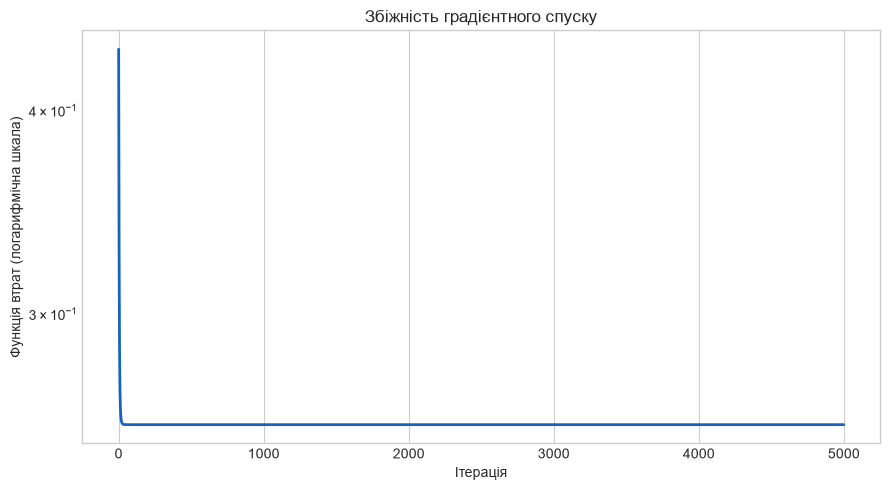

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(loss_history, color="#1565C0", linewidth=2)
ax.set_yscale("log")
ax.set(
    title="Збіжність градієнтного спуску",
    xlabel="Ітерація",
    ylabel="Функція втрат (логарифмічна шкала)",
)
plt.tight_layout()
plt.show()

## 7. Переведення параметрів градієнтного спуску в оригінальні одиниці

In [10]:
coefficients_gd = y_std * w_scaled_gd[1:] / X_std
intercept_gd = y_mean + y_std * w_scaled_gd[0] - coefficients_gd @ X_mean
w_gd = np.r_[intercept_gd, coefficients_gd]

parameter_names = ["intercept", *feature_names]
gd_parameters = pd.Series(w_gd, index=parameter_names, name="gradient_descent")
gd_parameters.to_frame()

,gradient_descent
intercept,-173171.607633
area,378.762754
bathrooms,1386049.497791
bedrooms,406820.033769


## 8. Аналітичне рішення

In [11]:
def analytical_solution(X, y):
    """Аналітичне рішення w = X⁺y через псевдообернену матрицю."""
    return np.linalg.pinv(X) @ y


X_design_raw = np.column_stack((np.ones(len(X_raw)), X_raw))
w_analytical = analytical_solution(X_design_raw, y_raw)

analytical_parameters = pd.Series(
    w_analytical,
    index=parameter_names,
    name="analytical",
)
analytical_parameters.to_frame()

,analytical
intercept,-173171.607633
area,378.762754
bathrooms,1386049.497791
bedrooms,406820.033769


## 9. Перевірка за допомогою `LinearRegression`

`LinearRegression` оцінює коефіцієнти методом найменших квадратів. Документація:
[scikit-learn LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).

In [12]:
sklearn_model = LinearRegression()
sklearn_model.fit(X_raw, y_raw)

w_sklearn = np.r_[sklearn_model.intercept_, sklearn_model.coef_]
sklearn_parameters = pd.Series(
    w_sklearn,
    index=parameter_names,
    name="scikit_learn",
)
sklearn_parameters.to_frame()

,scikit_learn
intercept,-173171.607633
area,378.762754
bathrooms,1386049.497791
bedrooms,406820.033769


## 10. Порівняння знайдених параметрів

In [13]:
parameters_comparison = pd.concat(
    [gd_parameters, analytical_parameters, sklearn_parameters],
    axis=1,
)
parameters_comparison["|GD - sklearn|"] = (
    parameters_comparison["gradient_descent"] - parameters_comparison["scikit_learn"]
).abs()
parameters_comparison["|analytical - sklearn|"] = (
    parameters_comparison["analytical"] - parameters_comparison["scikit_learn"]
).abs()
parameters_comparison

,gradient_descent,analytical,scikit_learn,|GD - sklearn|,|analytical - sklearn|
intercept,-173171.607633,-173171.607633,-173171.607633,0.000000,0.000000
area,378.762754,378.762754,378.762754,0.000000,0.000000
bathrooms,1386049.497791,1386049.497791,1386049.497791,0.000000,0.000000
bedrooms,406820.033769,406820.033769,406820.033769,0.000000,0.000000


## 11. Порівняння якості прогнозів

In [14]:
predictions_gd = hypothesis(X_design_raw, w_gd)
predictions_analytical = hypothesis(X_design_raw, w_analytical)
predictions_sklearn = sklearn_model.predict(X_raw)


def regression_metrics(y_true, y_pred):
    return {
        "MSE": mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²": r2_score(y_true, y_pred),
    }


metrics = pd.DataFrame(
    {
        "Gradient descent": regression_metrics(y_raw, predictions_gd),
        "Analytical": regression_metrics(y_raw, predictions_analytical),
        "Scikit-learn": regression_metrics(y_raw, predictions_sklearn),
    }
).T
metrics

,MSE,RMSE,R²
Gradient descent,1791170049977.319336,1338346.012800,0.487083
Analytical,1791170049977.319336,1338346.012800,0.487083
Scikit-learn,1791170049977.319336,1338346.012800,0.487083


### Перші десять фактичних і прогнозованих значень

In [15]:
predictions_comparison = pd.DataFrame(
    {
        "actual_price": y_raw,
        "gradient_descent": predictions_gd,
        "analytical": predictions_analytical,
        "scikit_learn": predictions_sklearn,
    }
)
predictions_comparison.head(10)

,actual_price,gradient_descent,analytical,scikit_learn
0,13300000.000000,7036627.154628,7036627.154628,7036627.154628
1,12250000.000000,10392020.790731,10392020.790731,10392020.790731
2,12250000.000000,7591864.514965,7591864.514965,7591864.514965
3,12215000.000000,7066928.174914,7066928.174914,7066928.174914
4,11410000.000000,5650577.656837,5650577.656837,5650577.656837
5,10850000.000000,8046157.638936,8046157.638936,8046157.638936
6,10150000.000000,8862041.446577,8862041.446577,8862041.446577
7,10150000.000000,12155033.662665,12155033.662665,12155033.662665
8,9870000.000000,5908136.329274,5908136.329274,5908136.329274
9,9800000.000000,5997273.322371,5997273.322371,5997273.322371


### Фактичні ціни проти прогнозованих

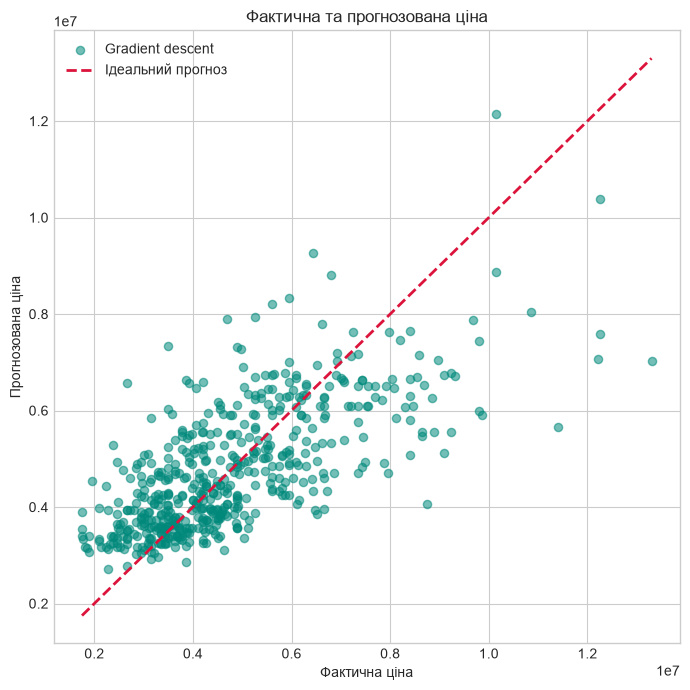

In [16]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_raw, predictions_gd, alpha=0.55, s=35, color="#00897B", label="Gradient descent")
limits = [min(y_raw.min(), predictions_gd.min()), max(y_raw.max(), predictions_gd.max())]
ax.plot(limits, limits, "--", color="crimson", linewidth=2, label="Ідеальний прогноз")
ax.set(
    title="Фактична та прогнозована ціна",
    xlabel="Фактична ціна",
    ylabel="Прогнозована ціна",
)
ax.legend()
plt.tight_layout()
plt.show()

## 12. Приклад прогнозу для нового будинку

In [17]:
new_house = pd.DataFrame(
    {"area": [6000], "bathrooms": [2], "bedrooms": [3]}
)
new_house_design = np.c_[np.ones(len(new_house)), new_house[feature_names].to_numpy()]

example_predictions = pd.Series(
    {
        "Gradient descent": hypothesis(new_house_design, w_gd)[0],
        "Analytical": hypothesis(new_house_design, w_analytical)[0],
        "Scikit-learn": sklearn_model.predict(new_house[feature_names].to_numpy())[0],
    },
    name="Прогнозована ціна",
)
print("Новий будинок: area=6000, bathrooms=2, bedrooms=3")
example_predictions.to_frame()

Новий будинок: area=6000, bathrooms=2, bedrooms=3


,Прогнозована ціна
Gradient descent,6091964.010768
Analytical,6091964.010768
Scikit-learn,6091964.010768
